In [1]:
import pandas as pd
import numpy as np
from numba import njit
import json

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata

from utils import get_BSM_data, sample_strikes

In [7]:
years = ['2017', '2018', '2019', '2020', '2021']
results = {}

print("Processing years 2017-2021...")
markets = ['nasdaq100']
for market in markets:
    for year in years:
        S0, mean, std, K = get_BSM_data(year, market)
        K_sampled = sample_strikes(S0, K, 5, 2)
        
        results[year] = {
            'S0': float(S0),
            'mean': float(mean),
            'std': float(std),
            'K_sampled': [float(k) for k in K_sampled],
        }
        print(f"  {year}: S0={S0:.2f}, sampled strikes={K_sampled}")

    output_path = f'./bsm_data_{market}_2017_2021.json'
    with open(output_path, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\nData saved to {output_path}")

Processing years 2017-2021...
  2017: S0=4910.75, sampled strikes=[4890, 4900, 4910, 4920, 4930]
  2018: S0=6512.56, sampled strikes=[6475, 6490, 6510, 6525, 6540]
  2019: S0=6362.69, sampled strikes=[6325, 6340, 6360, 6375, 6390]
  2020: S0=8873.25, sampled strikes=[8840, 8860, 8875, 8890, 8910]
  2021: S0=12692.73, sampled strikes=[12660, 12675, 12690, 12710, 12725]

Data saved to ./bsm_data_nasdaq100_2017_2021.json


In [1]:
import numpy as np
import pandas as pd
import json
from cma import CMA, CMAOptions
from utils import heston_call_price, heston_put_price, get_BSM_data, sample_strikes


# ============================================================
# HESTON PARAMETER BOUNDS + CONFIG
# ============================================================

PARAM_BOUNDS = {
    "v0":    (0.001, 0.15),    # Tighter: √v0 in [3%, 39%]
    "kappa": (0.5,   3.00),    # Reasonable mean reversion
    "theta": (0.001, 0.08),    # √θ in [3%, 28%]
    "rho":   (-0.95, -0.1),    # Must be negative for equities
    "xi":    (0.15,  0.80),    # Vol-of-vol: 15-80%
}

PARAM_NAMES = ["v0", "kappa", "theta", "rho", "xi"]
LOW = np.array([PARAM_BOUNDS[p][0] for p in PARAM_NAMES], float)
HIGH = np.array([PARAM_BOUNDS[p][1] for p in PARAM_NAMES], float)


# ============================================================
# LOSS FUNCTION (CMA-ES FRIENDLY)
# ============================================================

def heston_loss(params, market_prices, S, K, r, T, is_call, eps=1e-8):
    """
    Stable Heston objective for CMA-ES.
    Returns weighted relative MSE.
    """
    p = np.asarray(params, float)
    
    # Clip to bounds
    p = np.clip(p, LOW, HIGH)
    v0, kappa, theta, rho, xi = p

    try:
        # ---------- Price options ----------
        model = np.empty(len(S), dtype=float)
        valid_count = 0
        
        for i in range(len(S)):
            try:
                if is_call[i]:
                    price = heston_call_price(S[i], K[i], T[i], r[i],
                                              v0, kappa, theta, rho, xi,
                                              n_points=500)  # Faster
                else:
                    price = heston_put_price(S[i], K[i], T[i], r[i],
                                             v0, kappa, theta, rho, xi,
                                             n_points=500)
                
                if np.isfinite(price) and price > 0:
                    model[i] = price
                    valid_count += 1
                else:
                    model[i] = np.nan
            except:
                model[i] = np.nan
        
        # Need at least 50% valid prices
        if valid_count < len(S) * 0.5:
            return 1e8
        
        # ---------- Compute loss on valid prices ----------
        valid_mask = np.isfinite(model) & (model > 0) & (market_prices > 0)
        
        if np.sum(valid_mask) < 100:
            return 1e8
        
        model_valid = model[valid_mask]
        market_valid = market_prices[valid_mask]
        
        # Relative MSE (percentage error)
        eps_price = 5.0  # floor for option prices in the denominator
        scale = np.maximum(market_valid, eps_price)

        rel_error = (model_valid - market_valid) / scale
        loss = np.mean(rel_error ** 2)
        
        return loss

    except Exception as e:
        return 1e9


# ============================================================
# TEST PRICER FUNCTION
# ============================================================

def test_pricer():
    """Quick sanity check on the Heston pricer."""
    S, K, T, r = 2257.0, 2257.0, 0.25, 0.02
    v0, kappa, theta, rho, xi = 0.02, 1.5, 0.02, -0.7, 0.3
    
    call = heston_call_price(S, K, T, r, v0, kappa, theta, rho, xi)
    put = heston_put_price(S, K, T, r, v0, kappa, theta, rho, xi)
    
    print("Pricer sanity check:")
    print(f"  ATM Call (T=0.25): {call:.4f}")
    print(f"  ATM Put  (T=0.25): {put:.4f}")
    print(f"  Put-Call Parity check: C - P = {call - put:.4f}, S - K*e^(-rT) = {S - K*np.exp(-r*T):.4f}")
    
    if call > 0 and put > 0 and np.isfinite(call) and np.isfinite(put):
        print("  ✓ Pricer seems OK\n")
        return True
    else:
        print("  ✗ Pricer has issues!\n")
        return False


# ============================================================
# MAIN CALIBRATION LOOP
# ============================================================

def calibrate_heston_CMA(years=None, markets=None):
    if years is None:
        years = ["2017", "2018", "2019", "2020", "2021"]
    if markets is None:
        markets = ["alphabet", "apple", "microsoft", "nasdaq100"]

    # Test pricer first
    if not test_pricer():
        print("ERROR: Heston pricer failed sanity check. Aborting.")
        return {}

    all_results = {}

    for market in markets:
        print("\n" + "#" * 60)
        print(f"   CALIBRATING MARKET: {market.upper()}")
        print("#" * 60)
        
        all_results[market] = {}

        for year in years:
            print("\n" + "=" * 50)
            print(f"   CALIBRATING {market.upper()} - YEAR {year}")
            print("=" * 50 + "\n")

            # ----- Load summary data -----
            S0, mean, std, K_all = get_BSM_data(year, market=market)
            K_sampled = sample_strikes(S0, K_all, 5, 2)
            atmK = K_sampled[len(K_sampled) // 2]

            print(f"S0 = {S0:.2f}, Realized Vol = {std:.4f}, ATM Strike = {atmK:.2f}")

            # ----- Load entire option dataset -----
            df = pd.read_json(f"./option_data/{market}_{year}.json.bz2",
                              compression="bz2", orient="index")

            S = df["forward_price"].astype(float).values
            K = df["strike_price"].astype(float).values
            r = df["risk_free_rate"].astype(float).values
            T = df["tau"].astype(float).values
            price = df["option_price"].astype(float).values
            is_call = (df["is_call"].values == 1)

            # Filter valid options with reasonable moneyness
            moneyness = K / S
            valid = (
                (price > 0) & (S > 0) & (K > 0) &
                (T > 0.02) & (T < 2.0) &  # Exclude very short and very long maturities
                (moneyness > 0.8) & (moneyness < 1.2) &  # Focus on near-ATM
                np.isfinite(price) & np.isfinite(S) &
                np.isfinite(K) & np.isfinite(r) & np.isfinite(T)
            )

            S = S[valid]
            K = K[valid]
            r = r[valid]
            T = T[valid]
            price = price[valid]
            is_call = is_call[valid]

            print(f"Valid near-ATM options: {len(S):,}")

            # ----- Subsample for speed -----
            N = min(1500, len(S))
            np.random.seed(42)
            idx = np.random.choice(len(S), N, replace=False)

            S_ = S[idx]
            K_ = K[idx]
            r_ = r[idx]
            T_ = T[idx]
            price_ = price[idx]
            is_call_ = is_call[idx]

            print(f"Using sample of {N} options.")
            print(f"  T range: [{T_.min():.3f}, {T_.max():.3f}]")
            print(f"  K/S range: [{(K_/S_).min():.3f}, {(K_/S_).max():.3f}]")
            print(f"  Price range: [{price_.min():.2f}, {price_.max():.2f}]")

            # ============================================================
            # CMA-ES SETTINGS
            # ============================================================

            # Initial guess based on market vol
            v0_init = std ** 2  # Use realized vol squared
            x0 = np.array([v0_init, 1.5, v0_init, -0.7, 0.3])
            x0 = np.clip(x0, LOW, HIGH)
            
            print(f"\nInitial guess: v0={x0[0]:.4f}, κ={x0[1]:.2f}, θ={x0[2]:.4f}, ρ={x0[3]:.2f}, ξ={x0[4]:.2f}")

            sigma0 = 0.1

            opts = CMAOptions()
            opts["seed"] = 42
            opts["maxiter"] = 100
            opts["verb_disp"] = 0  # Quiet mode
            opts["bounds"] = [LOW.tolist(), HIGH.tolist()]
            opts["tolfun"] = 1e-6
            opts["popsize"] = 20  # Larger population

            # ============================================================
            # RUN CMA-ES
            # ============================================================

            print("\nRunning CMA-ES optimization...")
            es = CMA(x0, sigma0, options=opts)
            best_loss = float("inf")
            iteration = 0

            while not es.stop():
                cand = es.ask()
                fvals = [
                    heston_loss(c, price_, S_, K_, r_, T_, is_call_)
                    for c in cand
                ]

                es.tell(cand, fvals)
                current_best = min(fvals)
                if current_best < best_loss:
                    best_loss = current_best
                
                iteration += 1
                if iteration % 50 == 0:
                    print(f"  Iter {iteration}: Best Loss = {best_loss:.6f}")

            v0, kappa, theta, rho, xi = es.result.xbest

            print(f"\n✓ Best fit parameters:")
            print(f"  v0    = {v0:.6f}   (implied vol = {np.sqrt(v0)*100:.2f}%)")
            print(f"  kappa = {kappa:.4f}")
            print(f"  theta = {theta:.6f}   (long-term vol = {np.sqrt(theta)*100:.2f}%)")
            print(f"  rho   = {rho:.4f}")
            print(f"  xi    = {xi:.4f}")
            print(f"  Loss  = {best_loss:.6e}")
            print(f"  Market realized vol = {std*100:.2f}%")
            
            # Sanity check
            if best_loss > 1e6:
                print("  ⚠️  WARNING: Optimization did not converge!")
            elif best_loss > 1:
                print("  ⚠️  WARNING: Loss is high, fit may be poor")
            else:
                print("  ✓ Optimization converged successfully")

            all_results[market][year] = dict(
                S0=float(S0),
                v0=float(v0),
                kappa=float(kappa),
                theta=float(theta),
                rho=float(rho),
                xi=float(xi),
                loss=float(best_loss),
                atmK=float(atmK),
                K_sampled=[float(k) for k in K_sampled],
                annualized_vol=float(std),
                annualized_return=float(mean),
            )

        # Save results for this market
        output_file = f"heston_params_CMA_{market}.json"
        with open(output_file, "w") as f:
            json.dump(all_results[market], f, indent=2)
        print(f"\n→ Saved {market} results to {output_file}")

    return all_results


# ============================================================
# RUN + SAVE
# ============================================================

res = calibrate_heston_CMA()

print("\n" + "=" * 50)
print("All calibration results saved!")
print("=" * 50)

# Summary table
print("\nSUMMARY:")
for market, market_results in res.items():
    print(f"\n  {market.upper()}:")
    for year, params in market_results.items():
        print(f"    {year}: √v0={np.sqrt(params['v0'])*100:.1f}%, √θ={np.sqrt(params['theta'])*100:.1f}%, ρ={params['rho']:.2f}, Loss={params['loss']:.2e}")

Pricer sanity check:
  ATM Call (T=0.25): 68.0328
  ATM Put  (T=0.25): 56.7760
  Put-Call Parity check: C - P = 11.2568, S - K*e^(-rT) = 11.2568
  ✓ Pricer seems OK


############################################################
   CALIBRATING MARKET: ALPHABET
############################################################

   CALIBRATING ALPHABET - YEAR 2017

S0 = 808.17, Realized Vol = 0.1519, ATM Strike = 807.50
Valid near-ATM options: 368,733
Using sample of 1500 options.
  T range: [0.022, 1.997]
  K/S range: [0.800, 1.200]
  Price range: [0.05, 233.45]

Initial guess: v0=0.0231, κ=1.50, θ=0.0231, ρ=-0.70, ξ=0.30

Running CMA-ES optimization...


/Users/manu13/anaconda3/envs/MLClass/lib/python3.9/site-packages/cma/evolution_strategy.py:1531: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.49666666666666665 to stds[0]=0.049666666666666665
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


  Iter 50: Best Loss = 0.033579

✓ Best fit parameters:
  v0    = 0.031006   (implied vol = 17.61%)
  kappa = 1.4119
  theta = 0.079776   (long-term vol = 28.24%)
  rho   = -0.3418
  xi    = 0.7140
  Loss  = 3.357616e-02
  Market realized vol = 15.19%
  ✓ Optimization converged successfully

   CALIBRATING ALPHABET - YEAR 2018

S0 = 1073.65, Realized Vol = 0.2828, ATM Strike = 1072.50
Valid near-ATM options: 424,904
Using sample of 1500 options.
  T range: [0.022, 1.995]
  K/S range: [0.801, 1.200]
  Price range: [0.07, 289.00]

Initial guess: v0=0.0800, κ=1.50, θ=0.0800, ρ=-0.70, ξ=0.30

Running CMA-ES optimization...


/Users/manu13/anaconda3/envs/MLClass/lib/python3.9/site-packages/cma/evolution_strategy.py:1531: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.49666666666666665 to stds[0]=0.049666666666666665
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


  Iter 50: Best Loss = 0.066526
  Iter 100: Best Loss = 0.066524

✓ Best fit parameters:
  v0    = 0.052733   (implied vol = 22.96%)
  kappa = 1.9955
  theta = 0.080000   (long-term vol = 28.28%)
  rho   = -0.2908
  xi    = 0.8000
  Loss  = 6.652376e-02
  Market realized vol = 28.28%
  ✓ Optimization converged successfully

   CALIBRATING ALPHABET - YEAR 2019

S0 = 1055.32, Realized Vol = 0.2367, ATM Strike = 1055.00
Valid near-ATM options: 461,183
Using sample of 1500 options.
  T range: [0.022, 1.997]
  K/S range: [0.801, 1.197]
  Price range: [0.05, 313.25]

Initial guess: v0=0.0560, κ=1.50, θ=0.0560, ρ=-0.70, ξ=0.30

Running CMA-ES optimization...


...

  Iter 50: Best Loss = 0.246357

✓ Best fit parameters:
  v0    = 0.030862   (implied vol = 17.57%)
  kappa = 1.3513
  theta = 0.058539   (long-term vol = 24.19%)
  rho   = -0.9500
  xi    = 0.4367
  Loss  = 2.463564e-01
  Market realized vol = 16.38%
  ✓ Optimization converged successfully

   CALIBRATING NASDAQ100 - YEAR 2020

S0 = 8873.25, Realized Vol = 0.3665, ATM Strike = 8875.00
Valid near-ATM options: 1,442,893
Using sample of 1500 options.
  T range: [0.022, 1.997]
  K/S range: [0.801, 1.197]
  Price range: [0.18, 2845.00]

Initial guess: v0=0.1343, κ=1.50, θ=0.0800, ρ=-0.70, ξ=0.30

Running CMA-ES optimization...


/Users/manu13/anaconda3/envs/MLClass/lib/python3.9/site-packages/cma/evolution_strategy.py:1531: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.49666666666666665 to stds[0]=0.049666666666666665
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


  Iter 50: Best Loss = 0.255579

✓ Best fit parameters:
  v0    = 0.051062   (implied vol = 22.60%)
  kappa = 1.4738
  theta = 0.080000   (long-term vol = 28.28%)
  rho   = -0.9429
  xi    = 0.6559
  Loss  = 2.555787e-01
  Market realized vol = 36.65%
  ✓ Optimization converged successfully

   CALIBRATING NASDAQ100 - YEAR 2021

S0 = 12692.73, Realized Vol = 0.1853, ATM Strike = 12690.00
Valid near-ATM options: 2,216,847
Using sample of 1500 options.
  T range: [0.022, 1.978]
  K/S range: [0.800, 1.200]
  Price range: [0.18, 3903.20]

Initial guess: v0=0.0343, κ=1.50, θ=0.0343, ρ=-0.70, ξ=0.30

Running CMA-ES optimization...


/Users/manu13/anaconda3/envs/MLClass/lib/python3.9/site-packages/cma/evolution_strategy.py:1531: UserWarning: Sampling standard deviation i=0 (and 1 others) at iteration 0 multiplied by 0.49666666666666665 to stds[0]=0.049666666666666665
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


  Iter 50: Best Loss = 0.351950
  Iter 100: Best Loss = 0.351925

✓ Best fit parameters:
  v0    = 0.046220   (implied vol = 21.50%)
  kappa = 3.0000
  theta = 0.077021   (long-term vol = 27.75%)
  rho   = -0.9500
  xi    = 0.6632
  Loss  = 3.519249e-01
  Market realized vol = 18.53%
  ✓ Optimization converged successfully

→ Saved nasdaq100 results to heston_params_CMA_nasdaq100.json

All calibration results saved!

SUMMARY:

  ALPHABET:
    2017: √v0=17.6%, √θ=28.2%, ρ=-0.34, Loss=3.36e-02
    2018: √v0=23.0%, √θ=28.3%, ρ=-0.29, Loss=6.65e-02
    2019: √v0=20.3%, √θ=27.5%, ρ=-0.51, Loss=4.19e-02
    2020: √v0=29.1%, √θ=28.3%, ρ=-0.56, Loss=8.99e-02
    2021: √v0=23.8%, √θ=28.3%, ρ=-0.42, Loss=6.80e-02

  APPLE:
    2017: √v0=20.2%, √θ=27.7%, ρ=-0.34, Loss=5.65e-03
    2018: √v0=25.5%, √θ=28.3%, ρ=-0.40, Loss=2.25e-02
    2019: √v0=25.3%, √θ=28.3%, ρ=-0.58, Loss=1.12e-02
    2020: √v0=34.7%, √θ=28.3%, ρ=-0.95, Loss=4.88e-02
    2021: √v0=30.1%, √θ=28.3%, ρ=-0.69, Loss=1.39e-02

  MICR

In [2]:
from utils import convert_data_heston
import json


with open("heston_params_CMA.json", "r") as f:
    data = json.load(f)

# Now you can convert it:
params, S0, K, v0 = convert_data_heston(data)



In [6]:
v0

array([0.01138567, 0.01726342, 0.02133171, 0.02816137, 0.02585698])

In [26]:
atm_K, strikes = sample_strikes(S0, K, 5, 1)

In [27]:
strikes

[2245, 2250, 2255, 2260, 2265]

In [5]:
years = ['2017']

print("Starting to load datasets (expected time ~ 7 min)")
for y in years:
    path = f"./option_data/alphabet_{y}.json.bz2"
    df =  pd.read_json(path, compression='bz2', orient='index')

Starting to load datasets (expected time ~ 7 min)


In [6]:
df.head(7000)

,date,forward_price,time_to_maturity,tau,risk_free_rate,is_call,strike_price,option_price
0,2017-01-03,808.173790,10,0.027397,0.007398,1,747.5,60.75
1,2017-01-03,808.173790,10,0.027397,0.007398,1,760.0,48.20
2,2017-01-03,808.173790,10,0.027397,0.007398,1,762.5,45.80
3,2017-01-03,808.173790,10,0.027397,0.007398,1,765.0,43.45
4,2017-01-03,808.173790,10,0.027397,0.007398,1,767.5,41.30
...,...,...,...,...,...,...,...,...
6995,2017-01-09,828.197032,46,0.126027,0.009750,1,710.0,121.90
6996,2017-01-09,828.197032,46,0.126027,0.009750,1,720.0,112.35
6997,2017-01-09,828.197032,46,0.126027,0.009750,1,730.0,103.15
6998,2017-01-09,828.197032,46,0.126027,0.009750,1,740.0,94.00


In [ ]:
idx = df.groupby("date")["tau"].idxmin()
daily_spot = df.loc[idx, ["date", "forward_price"]].set_index("date").sort_index()
daily_spot.shape


(251, 1)

In [10]:
daily_spot["log_ret"] = np.log(daily_spot["forward_price"] / daily_spot["forward_price"].shift(1))

In [11]:
log_returns = daily_spot['log_ret'].dropna()

annualized_return = log_returns.mean() * 252

annualized_vol = log_returns.std() * np.sqrt(252)

print(f"Annualized Return: {annualized_return:.4f} ({annualized_return*100:.2f}%)")
print(f"Annualized Volatility: {annualized_vol:.4f} ({annualized_vol*100:.2f}%)")

Annualized Return: 0.1707 (17.07%)
Annualized Volatility: 0.0666 (6.66%)


In [ ]:
@njit
def bs_price_numba(S, K, r, T, sigma, is_call):
    if sigma <= 0.0 or T <= 0.0:
        return 0.0

    sqrtT = np.sqrt(T)
    d1 = (np.log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*sqrtT)
    d2 = d1 - sigma*sqrtT

    # Normal CDF (Numba-safe approximation)
    Nd1 = 0.5*(1.0 + np.math.erf(d1/np.sqrt(2)))
    Nd2 = 0.5*(1.0 + np.math.erf(d2/np.sqrt(2)))

    if is_call:
        return S*Nd1 - K*np.exp(-r*T)*Nd2
    else:
        return K*np.exp(-r*T)*(1.0-Nd2) - S*(1.0-Nd1)


@njit
def implied_vol_one(S, K, r, T, price, is_call):
    if price <= 0.0 or T <= 0.0:
        return np.nan

    low = 1e-8
    high = 5.0

    f_low = bs_price_numba(S, K, r, T, low, is_call) - price
    f_high = bs_price_numba(S, K, r, T, high, is_call) - price

    # No sign change → no root → return NaN
    if f_low * f_high > 0.0:
        return np.nan

    for _ in range(60):
        mid = 0.5*(low + high)
        f_mid = bs_price_numba(S, K, r, T, mid, is_call) - price
        if f_low * f_mid <= 0.0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5*(low + high)


In [17]:
@njit
def batch_implied_vol(S, K, r, T, price, is_call):
    n = len(S)
    out = np.empty(n)
    for i in range(n):
        out[i] = implied_vol_one(S[i], K[i], r[i], T[i], price[i], is_call[i])
    return out


In [18]:
S = df["forward_price"].values
K = df["strike_price"].values
r = df["risk_free_rate"].values
T = df["tau"].values
P = df["option_price"].values
is_call = (df["is_call"].values == 1)

df["implied_vol"] = batch_implied_vol(S, K, r, T, P, is_call)


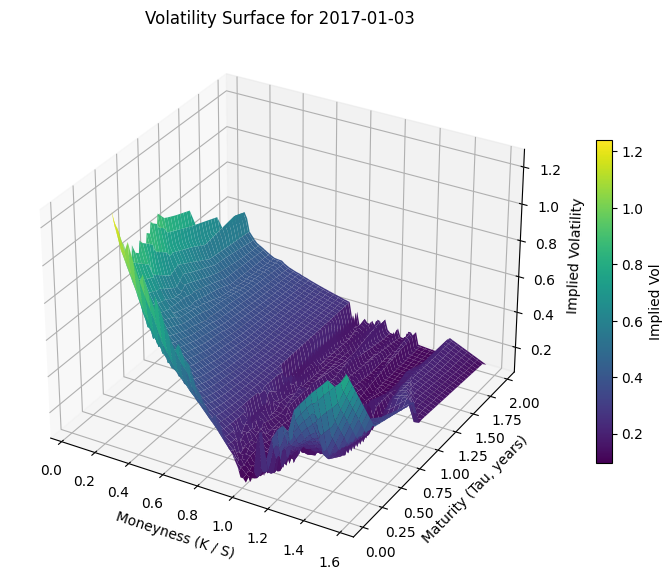

In [ ]:
date0 = "2017-01-03"
df0 = df[df["date"] == date0].copy()
df0 = df0.dropna(subset=["implied_vol"])

df0["moneyness"] = df0["strike_price"] / df0["forward_price"]

x = df0["moneyness"].values
y = df0["tau"].values
z = df0["implied_vol"].values

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x, y), z, (Xi, Yi), method="linear")

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(Xi, Yi, Zi, cmap="viridis", linewidth=0, antialiased=True)

ax.set_xlabel("Moneyness (K / S)")
ax.set_ylabel("Maturity (Tau, years)")
ax.set_zlabel("Implied Volatility")
ax.set_title(f"Volatility Surface for {date0}")

fig.colorbar(surf, shrink=0.6, label="Implied Vol")
plt.show()


In [ ]:



date0 = "2017-01-03"
df0 = df[df["date"] == date0].dropna(subset=["implied_vol"]).copy()

df0["moneyness"] = df0["strike_price"] / df0["forward_price"]

x = df0["moneyness"].values
y = df0["tau"].values
z = df0["implied_vol"].values

xi = np.linspace(x.min(), x.max(), 120)
yi = np.linspace(y.min(), y.max(), 120)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x, y), z, (Xi, Yi), method="linear")


fig = go.Figure(data=[go.Surface(
    x=Xi,
    y=Yi,
    z=Zi,
    colorscale="Viridis"
)])

fig.update_layout(
    title=f"Interactive Volatility Surface — {date0}",
    scene=dict(
        xaxis_title="Moneyness (K/S)",
        yaxis_title="Maturity (Tau, years)",
        zaxis_title="Implied Volatility",
    ),
    width=900,
    height=700,
)

fig.show()


In [22]:
df["implied_vol"]

0               NaN
1               NaN
2          0.086631
3          0.096416
4          0.100273
             ...   
2418504    0.344918
2418505    0.334788
2418506    0.334788
2418507    0.378947
2418508    0.378947
Name: implied_vol, Length: 2418509, dtype: float64

In [23]:
mean_iv = df["implied_vol"].mean()


In [24]:
mean_iv

0.20148236291954458

In [ ]:
df["moneyness"] = df["strike_price"] / df["forward_price"]


atm = df[np.abs(df["moneyness"] - 1.0) < 0.01]


daily_atm_iv = atm.groupby("date")["implied_vol"].mean()


mean_annual_iv = daily_atm_iv.mean()

print(mean_annual_iv)


0.09238198833393205


In [30]:
# ---- Calls table ----
calls_table = (
    df[df["is_call"] == 1][["strike_price", "implied_vol"]]
    .dropna()
    .sort_values("strike_price")
    .reset_index(drop=True)
)

# ---- Puts table ----
puts_table = (
    df[df["is_call"] == -1][["strike_price", "implied_vol"]]
    .dropna()
    .sort_values("strike_price")
    .reset_index(drop=True)
)

calls_table[calls_table["strike_price"] == 2200].mean()


strike_price    2200.000000
implied_vol        0.153316
dtype: float64